# Flights EDA (Seaborn `flights` dataset)

Author: Senior Data Scientist

This notebook performs an end-to-end Exploratory Data Analysis: loading, cleaning, feature engineering, statistical analysis, time-series trend, seasonality detection, monthly/yearly growth, and correlation analysis with publication-quality visualizations.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 18,
    'axes.labelsize': 14
})

df = sns.load_dataset('flights')
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [3]:
df.info()
df.describe(include='all')
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


year          0
month         0
passengers    0
dtype: int64

In [5]:
# --- Data Cleaning ---
df = df.copy()
df['passengers'] = pd.to_numeric(df['passengers'], errors='coerce')
df = df.dropna(subset=['passengers'])

# Remove duplicates if any
df = df.drop_duplicates(subset=['year','month'])

# Standardize month ordering
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
df = df.sort_values(['year','month']).reset_index(drop=True)
df.tail(10)

,year,month,passengers
134,1960,Mar,419
135,1960,Apr,461
136,1960,May,472
137,1960,Jun,535
138,1960,Jul,622
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390
143,1960,Dec,432


## Chart 1: Passengers over time (raw)
**Interpretation:** The series exhibits a clear upward trend and repeating seasonal patterns, suggesting multiplicative seasonality (growth rate increases with level).

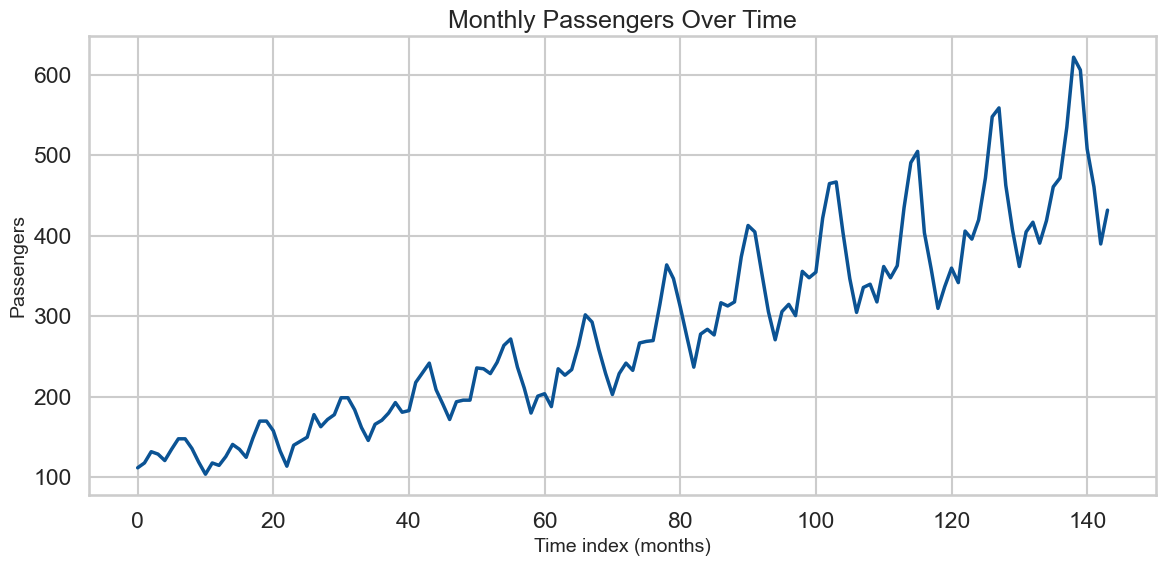

In [6]:
plt.figure()
sns.lineplot(data=df, x=df.index, y='passengers', linewidth=2.5, color='#0b5394')
plt.title('Monthly Passengers Over Time')
plt.xlabel('Time index (months)')
plt.ylabel('Passengers')
plt.tight_layout()
plt.show()

In [8]:
# --- Feature Engineering ---
df['month_num'] = df['month'].cat.codes + 1
df['time_index'] = np.arange(len(df))
df['log_passengers'] = np.log1p(df['passengers'])

df['rolling_mean_12'] = df['passengers'].rolling(12, min_periods=1).mean()
df['rolling_median_12'] = df['passengers'].rolling(12, min_periods=1).median()

df['mom_growth_pct'] = df['passengers'].pct_change(periods=1) * 100
df['yoy_growth_pct'] = df['passengers'].pct_change(periods=12) * 100
df.head(10)

,year,month,passengers,month_num,time_index,log_passengers,rolling_mean_12,rolling_median_12,mom_growth_pct,yoy_growth_pct
0,1949,Jan,112,1,0,4.727388,112.000000,112.0,NaN,NaN
1,1949,Feb,118,2,1,4.779123,115.000000,115.0,5.357143,NaN
2,1949,Mar,132,3,2,4.890349,120.666667,118.0,11.864407,NaN
3,1949,Apr,129,4,3,4.867534,122.750000,123.5,-2.272727,NaN
4,1949,May,121,5,4,4.804021,122.400000,121.0,-6.201550,NaN
5,1949,Jun,135,6,5,4.912655,124.500000,125.0,11.570248,NaN
6,1949,Jul,148,7,6,5.003946,127.857143,129.0,9.629630,NaN
7,1949,Aug,148,8,7,5.003946,130.375000,130.5,0.000000,NaN
8,1949,Sep,136,9,8,4.919981,131.000000,132.0,-8.108108,NaN
9,1949,Oct,119,10,9,4.787492,129.800000,130.5,-12.500000,NaN


## Chart 2: Trend via 12-month rolling mean
**Interpretation:** The rolling mean smooths the seasonal fluctuations, revealing a persistent upward trend—evidence that the growth is structural rather than purely seasonal.

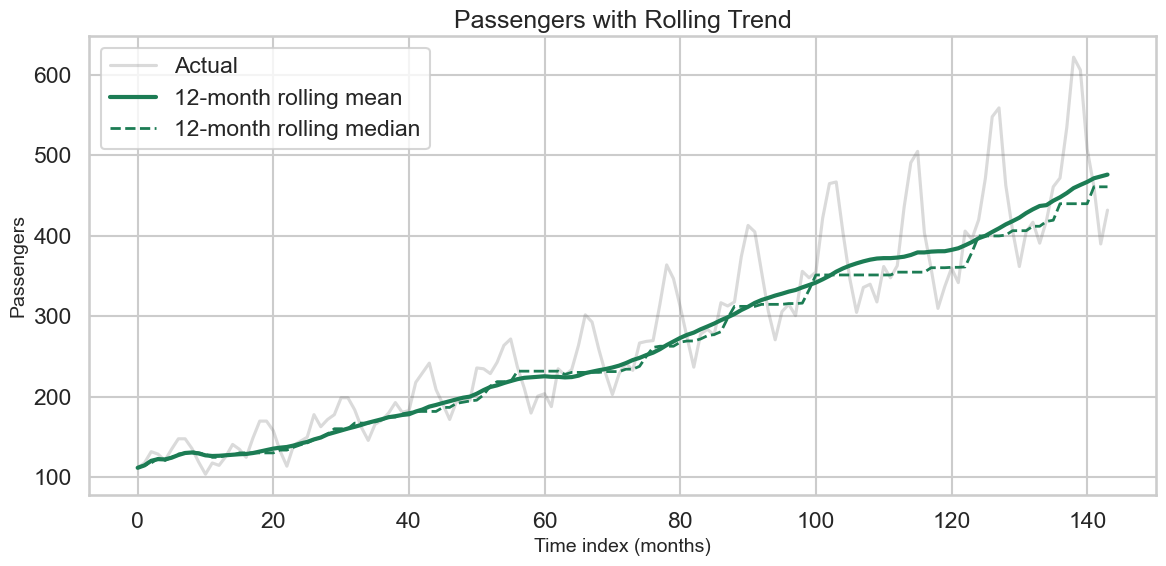

In [9]:
plt.figure()
plt.plot(df.index, df['passengers'], alpha=0.25, label='Actual', color='#6d6d6d')
plt.plot(df.index, df['rolling_mean_12'], linewidth=3, label='12-month rolling mean', color='#1c7c54')
plt.plot(df.index, df['rolling_median_12'], linewidth=2, linestyle='--', label='12-month rolling median', color='#1c7c54')
plt.title('Passengers with Rolling Trend')
plt.xlabel('Time index (months)')
plt.ylabel('Passengers')
plt.legend()
plt.tight_layout()
plt.show()

## Chart 3: Monthly seasonality (boxplot by month)
**Interpretation:** If month boxes are well separated, it indicates stable seasonal effects. Consistent medians/means across years imply seasonality with near-fixed phase.

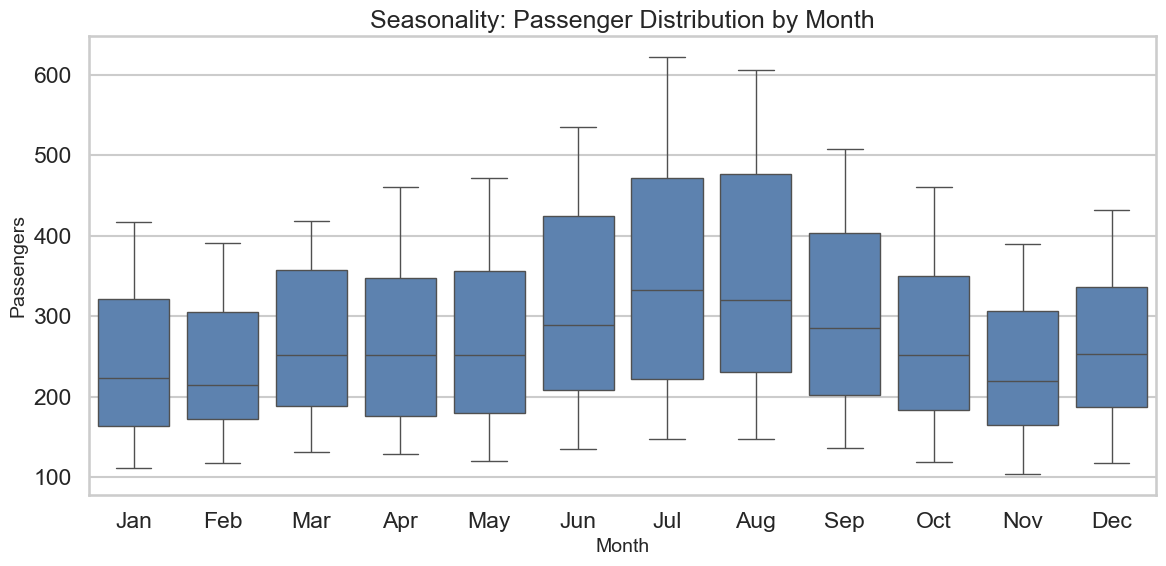

In [10]:
plt.figure()
sns.boxplot(data=df, x='month', y='passengers', color='#4f81bd')
plt.title('Seasonality: Passenger Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.tight_layout()
plt.show()

## Chart 4: Average passengers per month
**Interpretation:** This chart summarizes the typical level for each month. Peaks correspond to months where capacity/demand strategy should be strongest. Troughs highlight opportunities for off-peak initiatives.

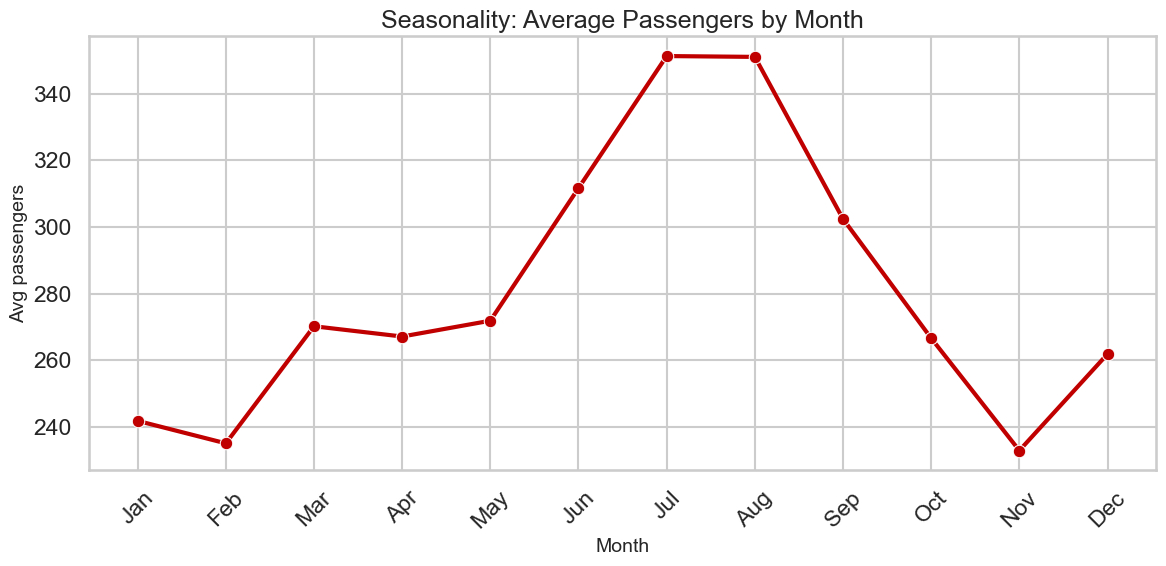

In [14]:
month_avg = df.groupby('month', observed=True)['passengers'].mean().reindex(pd.Categorical(month_order, categories=month_order, ordered=True))
plt.figure()
sns.lineplot(x=range(1,13), y=month_avg.values, marker='o', linewidth=3, color='#c00000')
plt.xticks(range(1,13), month_order, rotation=45)
plt.title('Seasonality: Average Passengers by Month')
plt.xlabel('Month')
plt.ylabel('Avg passengers')
plt.tight_layout()
plt.show()

## Chart 5: Correlation heatmap (time features vs passengers)
**Interpretation:** High correlation for trend-related features (`year`, `time_index`, rolling stats) indicates that most variance is explained by progression over time. Low/structured correlations for month-derived features indicate seasonality is present but contributes separately from the trend.

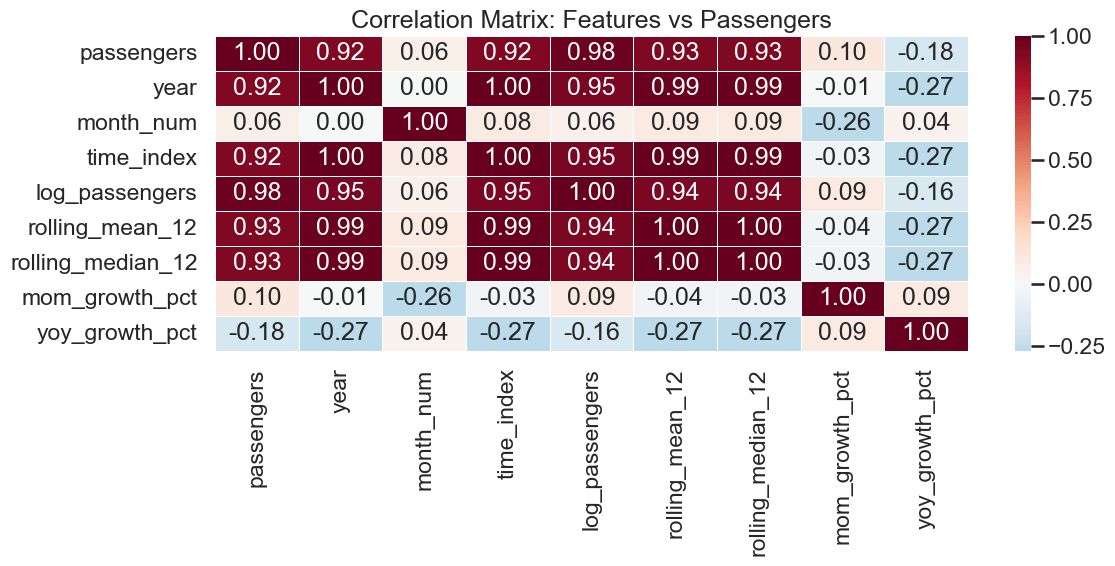

In [ ]:
corr_df = df[['passengers','year','month_num','time_index','log_passengers','rolling_mean_12','rolling_median_12','mom_growth_pct','yoy_growth_pct']].copy()
corr = corr_df.corr(numeric_only=True)
plt.figure()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.6)
plt.title('Correlation Matrix: Features vs Passengers')
plt.tight_layout()
plt.show()

## Chart 6: MoM growth distribution
**Interpretation:** Month-over-month growth captures short-term swings driven by seasonality and year-level changes. Outliers can flag unusually strong demand spikes.

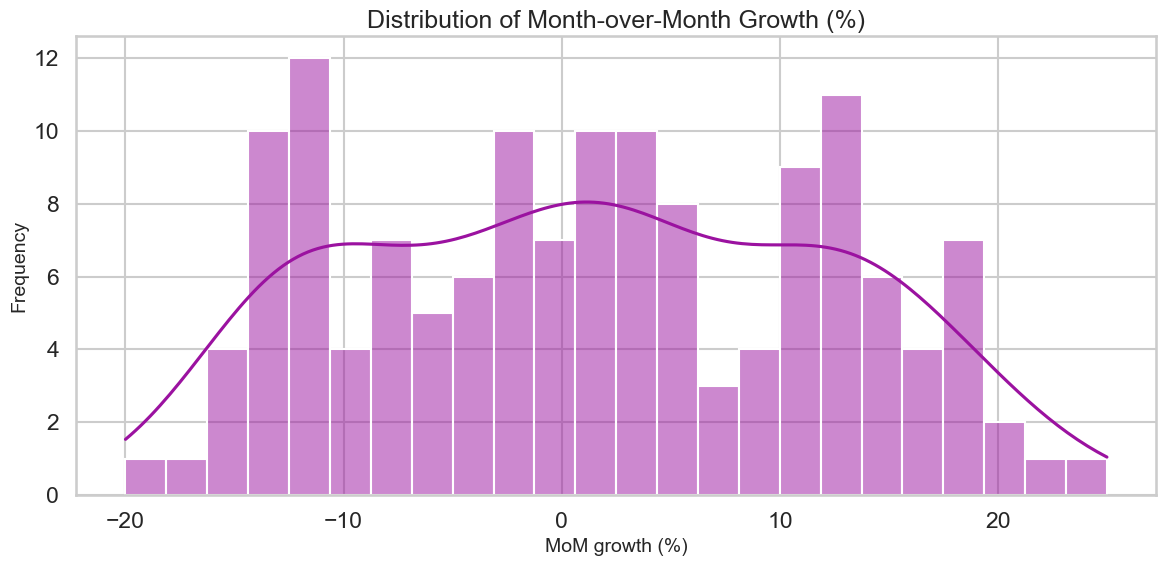

In [ ]:
plt.figure()
sns.histplot(df['mom_growth_pct'].dropna(), bins=24, kde=True, color="#8f12a0")
plt.title('Distribution of Month-over-Month Growth (%)')
plt.xlabel('MoM growth (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Chart 7: YoY growth by year
**Interpretation:** Year-over-year growth reduces noise from within-year seasonality by comparing the same month across adjacent years. Trends in YoY growth indicate whether the airline market is accelerating or stabilizing.

C:\Users\Admin\AppData\Local\Temp\ipykernel_19880\478817286.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yoy_year.index.astype(int), y=yoy_year.values, palette='viridis')


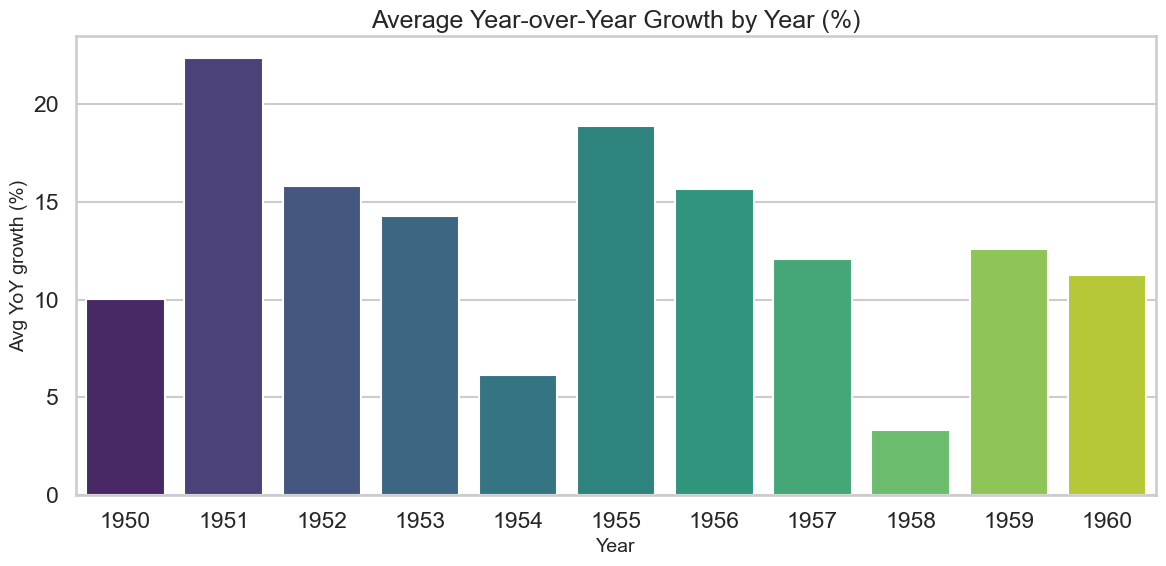

In [17]:
yoy_year = df.groupby('year')['yoy_growth_pct'].mean().dropna()
plt.figure()
sns.barplot(x=yoy_year.index.astype(int), y=yoy_year.values, palette='viridis')
plt.title('Average Year-over-Year Growth by Year (%)')
plt.xlabel('Year')
plt.ylabel('Avg YoY growth (%)')
plt.tight_layout()
plt.show()

## Chart 8: Monthly growth heatmap (YoY by month)
**Interpretation:** A heatmap of YoY growth by month highlights which seasonal periods are growing faster. This enables month-targeted capacity planning and marketing.

C:\Users\Admin\AppData\Local\Temp\ipykernel_19880\1173324763.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['month','year'])['yoy_growth_pct']


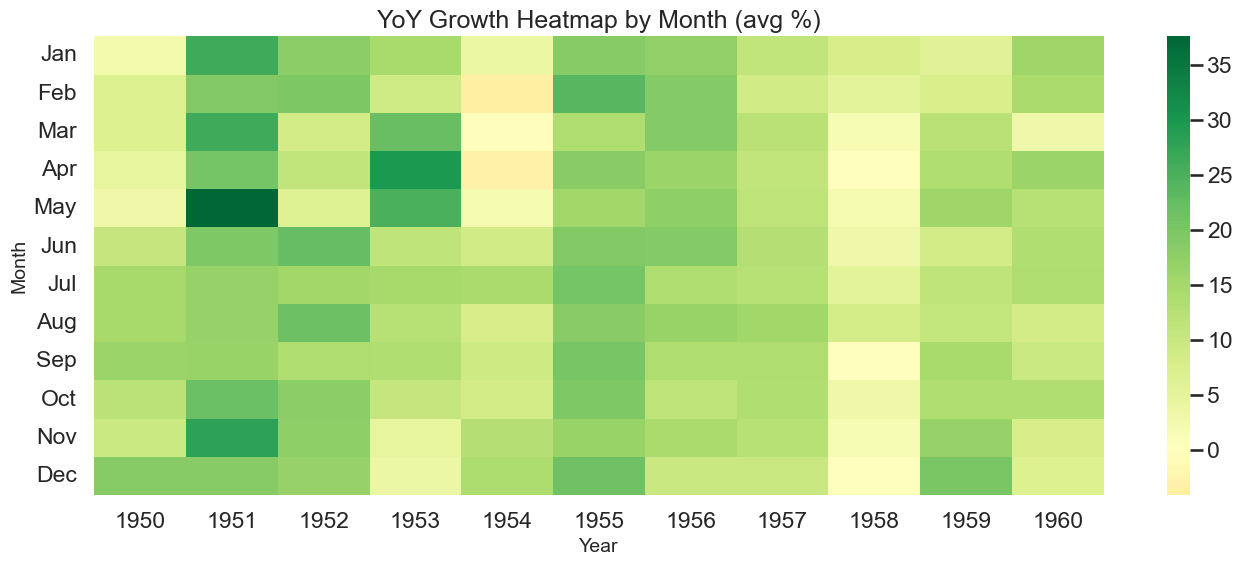

In [22]:
df_yoy_month = (
    df.dropna(subset=['yoy_growth_pct'])
      .groupby(['month','year'])['yoy_growth_pct']
      .mean()
      .reset_index()
      .pivot(index='month', columns='year', values='yoy_growth_pct')
      .reindex(month_order)
 )
plt.figure(figsize=(14,6))
sns.heatmap(df_yoy_month, cmap='RdYlGn', center=0, annot=False)
plt.title('YoY Growth Heatmap by Month (avg %)')
plt.xlabel('Year')
plt.ylabel('Month')
plt.tight_layout()
plt.show()

## Executive Recommendations
1. Forecast with seasonality: employ models that incorporate yearly seasonality and a trend component (multiplicative or log-linear).
2. Capacity planning: allocate additional seats/crew ahead of peak months identified in the seasonality plots.
3. Revenue strategy: run targeted promotions during consistent trough months to reduce demand volatility.
4. KPI design: track both MoM and YoY metrics, but rely more on YoY for business decisions to neutralize seasonal noise.
5. Monitoring: watch rolling mean drift; a sustained change may indicate market growth or structural shifts beyond normal seasonality.